<a href="https://colab.research.google.com/github/thanosleggis/Thesis/blob/main/notebooks/EGG_CNN_DEAP_LRP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Συνδέομαι με το Google Drive...
Mounted at /content/drive

 Βρέθηκε ο φάκελος: /content/drive/MyDrive/DEAP.mini
 Περιέχει 31 αρχεία .dat
 Ξεκινάει η φόρτωση 31 εθελοντών. Αυτό θα πάρει λίγα λεπτά...
    Φόρτωση 1/31: s01.dat...
    Φόρτωση 6/31: s06.dat...
    Φόρτωση 11/31: s11.dat...
    Φόρτωση 16/31: s16.dat...
    Φόρτωση 21/31: s21.dat...
    Φόρτωση 26/31: s26.dat...
    Φόρτωση 31/31: s31.dat...

 ΟΛΑ τα δεδομένα φορτώθηκαν!
 Σύνολο δειγμάτων: 146320
 Εκπαίδευση σε 117056 δείγματα, Test σε 29264 δείγματα.

 Έναρξη Εκπαίδευσης (Full Dataset)...
Epoch 1/2
915/915 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7779 - loss: 0.4999 - val_accuracy: 0.7795 - val_loss: 0.4830
Epoch 2/2
915/915 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.7833 - loss: 0.4861 - val_accuracy: 0.7881 - val_loss: 0.4800
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7881 - loss: 0.4800

 ΤΕΛΙΚΗ ΑΚΡΙΒΕΙΑ (Γενικό Μοντέλο): 78.81%

 Ξεκινάει η ανάλυση Επεξηγησιμότητας (LRP / Input x Gradient)...

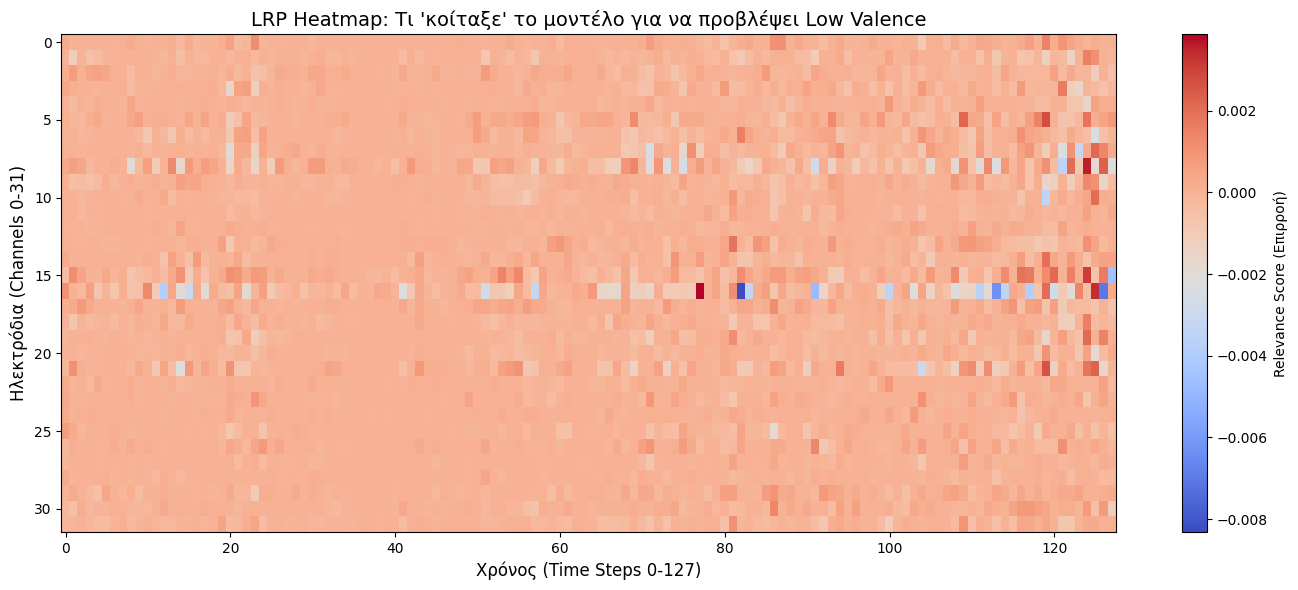


 Ξεκινάει το Subject-Specific Fine-Tuning...
 Επιλέχθηκε τυχαία ο εθελοντής: s30.dat
 Φόρτωση δεδομένων για τον εθελοντή: s30.dat
 Ακρίβεια στον εθελοντή ΠΡΙΝ το Fine-Tuning: 72.56%

 Ξεκινάει η μικρο-ρύθμιση (Fine-Tuning) για 10 epochs...
Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7471 - loss: 0.5423 - val_accuracy: 0.7172 - val_loss: 0.5542
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7481 - loss: 0.5338 - val_accuracy: 0.6864 - val_loss: 0.5769
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7450 - loss: 0.5318 - val_accuracy: 0.6981 - val_loss: 0.5800
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7511 - loss: 0.5293 - val_accuracy: 0.6939 - val_loss: 0.5684
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7500 - loss: 0.5255 - val_accuracy: 0.7182 - val_loss: 0.5525
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7479 - loss: 0.5271 - val_accuracy: 0.7235 - val_

In [ ]:
# --- 0. ΕΓΚΑΤΑΣΤΑΣΗ ΑΠΑΡΑΙΤΗΤΩΝ ΒΙΒΛΙΟΘΗΚΩΝ ---
# (Δεν χρειάζεται πλέον το LIME, χρησιμοποιούμε εγγενές TensorFlow)

# --- 1. ΕΙΣΑΓΩΓΗ ΒΙΒΛΙΟΘΗΚΩΝ ---
import os
import pickle
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from google.colab import drive
import matplotlib.pyplot as plt

# --- 2. ΣΥΝΔΕΣΗ ΜΕ GOOGLE DRIVE ---
print(" Συνδέομαι με το Google Drive...")
drive.mount('/content/drive', force_remount=True)

# --- 3. ΕΥΡΕΣΗ ΦΑΚΕΛΟΥ ΔΕΔΟΜΕΝΩΝ ---
possible_paths = [
    '/content/drive/MyDrive/DEAP.mini',
    '/content/drive/MyDrive/DEAP_mini',
    '/content/drive/MyDrive/deap_mini'
]

DATA_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        files_inside = os.listdir(path)
        dat_count = sum(1 for f in files_inside if f.endswith('.dat'))
        if dat_count > 0:
            DATA_PATH = path
            print(f"\n Βρέθηκε ο φάκελος: {DATA_PATH}")
            print(f" Περιέχει {dat_count} αρχεία .dat")
            break

if DATA_PATH is None:
    print(" Δεν βρέθηκε ο φάκελος! Βεβαιώσου ότι είναι στο My Drive.")
else:
    # --- 4. ΡΥΘΜΙΣΕΙΣ (HYPERPARAMETERS) ---
    WINDOW_SIZE = 128
    STRIDE = 64
    CHANNELS = 32
    EPOCHS = 2  # Αν θέλεις να τρέξει γρήγορα, κάντο 2-3
    BATCH_SIZE = 128

    # --- 5. ΣΥΝΑΡΤΗΣΗ ΦΟΡΤΩΣΗΣ ΔΕΔΟΜΕΝΩΝ ---
    def load_all_subjects(folder):
        files = [f for f in os.listdir(folder) if f.endswith('.dat')]
        files.sort()

        all_X = []
        all_y = []

        print(f" Ξεκινάει η φόρτωση {len(files)} εθελοντών. Αυτό θα πάρει λίγα λεπτά...")

        for idx, filename in enumerate(files):
            file_path = os.path.join(folder, filename)

            if idx % 5 == 0:
                print(f"    Φόρτωση {idx+1}/{len(files)}: {filename}...")

            try:
                with open(file_path, 'rb') as f:
                    content = pickle.load(f, encoding='latin1')

                data = content['data']
                labels = content['labels']

                for i in range(len(data)):
                    trial_signal = data[i, :32, :].T.astype('float32')
                    clean_signal = trial_signal[384:, :] # Baseline removal
                    label = 0 if labels[i, 0] < 5 else 1 # Label Valence

                    for start in range(0, clean_signal.shape[0] - WINDOW_SIZE, STRIDE):
                        end = start + WINDOW_SIZE
                        window = clean_signal[start:end, :]
                        if window.shape[0] == WINDOW_SIZE:
                            all_X.append(window)
                            all_y.append(label)

            except Exception as e:
                print(f" Σφάλμα στο {filename}: {e}")

        return np.array(all_X, dtype='float32'), np.array(all_y, dtype='int')

    # --- 6. ΕΚΤΕΛΕΣΗ ΠΡΟΕΤΟΙΜΑΣΙΑΣ ---
    X, y = load_all_subjects(DATA_PATH)

    if len(X) > 0:
        print(f"\n ΟΛΑ τα δεδομένα φορτώθηκαν!")
        print(f" Σύνολο δειγμάτων: {X.shape[0]}")

        y = to_categorical(y, 2)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        print(f" Εκπαίδευση σε {len(X_train)} δείγματα, Test σε {len(X_test)} δείγματα.")

        # --- 7. ΚΑΤΑΣΚΕΥΗ ΜΟΝΤΕΛΟΥ (CNN-RNN) ---
        inputs = Input(shape=(WINDOW_SIZE, CHANNELS))

        x = Conv1D(64, 3, activation='relu', padding='same')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling1D(2)(x)
        x = Dropout(0.3)(x)

        x = Conv1D(128, 3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(2)(x)
        x = Dropout(0.3)(x)

        x = LSTM(128)(x)
        x = Dropout(0.4)(x)

        x = Dense(64, activation='relu')(x)
        outputs = Dense(2, activation='softmax')(x)

        model = Model(inputs, outputs)
        model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

        # --- 8. ΕΚΠΑΙΔΕΥΣΗ ΜΟΝΤΕΛΟΥ ---
        print("\n Έναρξη Εκπαίδευσης (Full Dataset)...")
        history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_test, y_test))

        # --- 9. ΑΞΙΟΛΟΓΗΣΗ ΜΟΝΤΕΛΟΥ ---
        loss, acc = model.evaluate(X_test, y_test)
        print("\n========================================")
        print(f" ΤΕΛΙΚΗ ΑΚΡΙΒΕΙΑ (Γενικό Μοντέλο): {acc*100:.2f}%")
        print("========================================")

        # --- 10. ΕΠΕΞΗΓΗΣΙΜΟΤΗΤΑ (LRP / RELEVANCE PROPAGATION) ---
        print("\n Ξεκινάει η ανάλυση Επεξηγησιμότητας (LRP / Input x Gradient)...")

        # Επιλέγουμε το πρώτο δείγμα από το Test set
        sample_idx = 0
        input_data = X_test[sample_idx:sample_idx+1] # Διατηρούμε το batch dimension (1, 128, 32)
        true_label = np.argmax(y_test[sample_idx])

        # Μετατροπή σε tf.Tensor για τον υπολογισμό των Gradients
        input_tensor = tf.convert_to_tensor(input_data, dtype=tf.float32)

        # Καταγραφή των πράξεων για να βρούμε το Gradient (Relevance)
        with tf.GradientTape() as tape:
            tape.watch(input_tensor)
            predictions = model(input_tensor)

            # Βρίσκουμε την κλάση που "κέρδισε"
            target_class = tf.argmax(predictions[0])
            target_score = predictions[0, target_class]

        # Υπολογισμός Gradients του τελικού σκορ ως προς τα αρχικά σήματα εισόδου (ΗΕΓ)
        gradients = tape.gradient(target_score, input_tensor)

        # LRP Approximation (Input x Gradient)
        # Μαθηματικά ισοδύναμο με το Taylor Decomposition για ReLU δίκτυα
        relevance_scores = gradients * input_tensor
        relevance_scores = relevance_scores[0].numpy() # Αφαίρεση του batch dimension -> (128, 32)

        # --- Οπτικοποίηση του LRP (Heatmap) ---
        plt.figure(figsize=(14, 6))

        # Κάνουμε transpose (relevance_scores.T) για να είναι τα Κανάλια (32) στον άξονα Y
        # και ο Χρόνος (128) στον άξονα X.
        heatmap = plt.imshow(relevance_scores.T, aspect='auto', cmap='coolwarm')
        plt.colorbar(heatmap, label='Relevance Score (Επιρροή)')

        class_name = "High Valence" if target_class == 1 else "Low Valence"
        plt.title(f"LRP Heatmap: Τι 'κοίταξε' το μοντέλο για να προβλέψει {class_name}", fontsize=14)
        plt.ylabel('Ηλεκτρόδια (Channels 0-31)', fontsize=12)
        plt.xlabel('Χρόνος (Time Steps 0-127)', fontsize=12)
        plt.tight_layout()
        plt.show()

        # --- 11. SUBJECT-SPECIFIC FINE-TUNING ---
        print("\n Ξεκινάει το Subject-Specific Fine-Tuning...")

        def load_single_subject(folder, filename):
            file_path = os.path.join(folder, filename)
            with open(file_path, 'rb') as f:
                content = pickle.load(f, encoding='latin1')

            data = content['data']
            labels = content['labels']

            X_sub, y_sub = [], []
            for i in range(len(data)):
                trial_signal = data[i, :32, :].T.astype('float32')
                clean_signal = trial_signal[384:, :]
                label = 0 if labels[i, 0] < 5 else 1

                for start in range(0, clean_signal.shape[0] - WINDOW_SIZE, STRIDE):
                    end = start + WINDOW_SIZE
                    window = clean_signal[start:end, :]
                    if window.shape[0] == WINDOW_SIZE:
                        X_sub.append(window)
                        y_sub.append(label)

            return np.array(X_sub, dtype='float32'), to_categorical(np.array(y_sub, dtype='int'), 2)

        subject_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.dat')]
        target_subject = random.choice(subject_files)

        print(f" Επιλέχθηκε τυχαία ο εθελοντής: {target_subject}")
        print(f" Φόρτωση δεδομένων για τον εθελοντή: {target_subject}")
        X_sub, y_sub = load_single_subject(DATA_PATH, target_subject)

        X_sub_train, X_sub_test, y_sub_train, y_sub_test = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)

        loss_before, acc_before = model.evaluate(X_sub_test, y_sub_test, verbose=0)
        print(f" Ακρίβεια στον εθελοντή ΠΡΙΝ το Fine-Tuning: {acc_before*100:.2f}%")

        for layer in model.layers[:-4]:
            layer.trainable = False

        model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

        print("\n Ξεκινάει η μικρο-ρύθμιση (Fine-Tuning) για 10 epochs...")
        history_ft = model.fit(X_sub_train, y_sub_train, epochs=10, batch_size=32, validation_data=(X_sub_test, y_sub_test))

        loss_after, acc_after = model.evaluate(X_sub_test, y_sub_test, verbose=0)
        print("\n========================================")
        print(f" ΑΚΡΙΒΕΙΑ ΣΤΟΝ ΕΘΕΛΟΝΤΗ '{target_subject}' ΜΕΤΑ ΤΟ FINE-TUNING: {acc_after*100:.2f}%")

        improvement = (acc_after - acc_before) * 100
        if improvement > 0:
            print(f" Συνολική βελτίωση: +{improvement:.2f}% ")
        else:
            print(f" Διαφορά: {improvement:.2f}% (Το μοντέλο είχε ήδη πιάσει την οροφή του!)")
        print("========================================")

    else:
        print(" Πρόβλημα: Δεν βρέθηκαν δεδομένα.")